# 02 · Sales, product & customer analysis

All numbers come from the functions in `src/analysis.py` – the same functions that power the dashboard and the
Excel report, so every output agrees.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 20)
plt.rcParams.update({"figure.figsize": (10, 4), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e8e7e3", "axes.axisbelow": True})
BLUE = "#2a78d6"

from src import analysis as an
sales, returns = an.load_clean()
k = an.kpis(sales, returns)
{key: round(v, 3) for key, v in k.items()}

{'revenue': 19327697.16,
 'orders': 39510,
 'customers': 5852,
 'units': 10912631,
 'aov': 489.185,
 'returned_value': 434604.86,
 'return_rate': 0.022}

## 1. Sales trends
### Monthly

,period,revenue,orders,customers,aov
12,2010-12-01,775638.0,1550,884,500.4
13,2011-01-01,578036.0,1079,738,535.7
14,2011-02-01,507639.0,1092,756,464.9
15,2011-03-01,689708.0,1440,973,479.0
16,2011-04-01,500820.0,1235,853,405.5
17,2011-05-01,739902.0,1668,1054,443.6
18,2011-06-01,736726.0,1525,990,483.1
19,2011-07-01,688145.0,1452,946,473.9
20,2011-08-01,724197.0,1339,933,540.8
21,2011-09-01,1028314.0,1818,1259,565.6


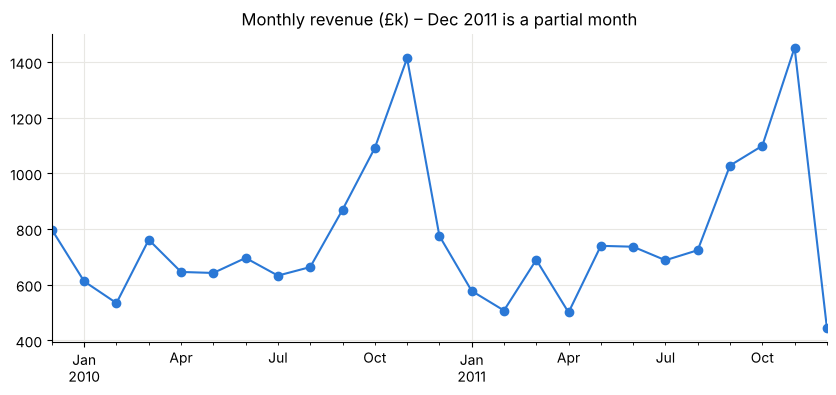

In [2]:
m = an.sales_trend(sales, "MS")
ax = m.set_index("period")["revenue"].div(1e3).plot(color=BLUE, marker="o")
ax.set(title="Monthly revenue (£k) – Dec 2011 is a partial month", xlabel="", ylabel="")
m.assign(revenue=m.revenue.round(0), aov=m.aov.round(1)).tail(13)

Revenue rises every autumn and peaks in November (Christmas stock-up by gift-shop buyers),
then drops sharply in December–February.

### Weekly

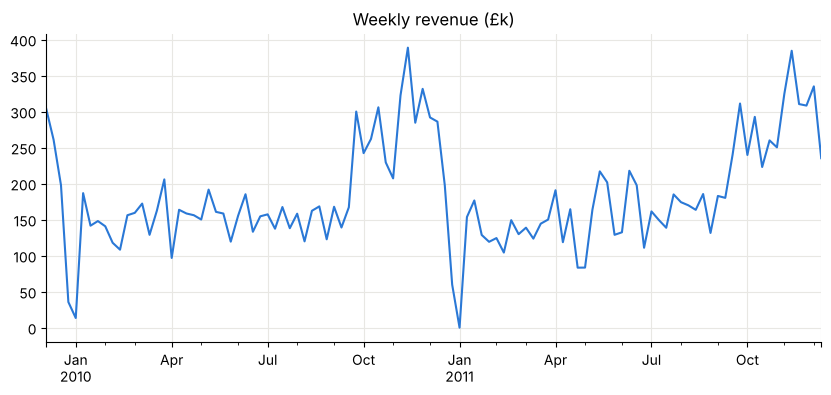

In [3]:
w = an.sales_trend(sales, "W-MON")
ax = w.set_index("period")["revenue"].div(1e3).plot(color=BLUE)
ax.set(title="Weekly revenue (£k)", xlabel="", ylabel="");

### Day of week and hour of day

,weekday,revenue,orders
0,Monday,3387763.43,6245
1,Tuesday,3786308.90,7145
2,Wednesday,3374301.02,7114
3,Thursday,3991209.38,8167
4,Friday,2994333.37,5986
5,Saturday,9803.05,30
6,Sunday,1783978.01,4823


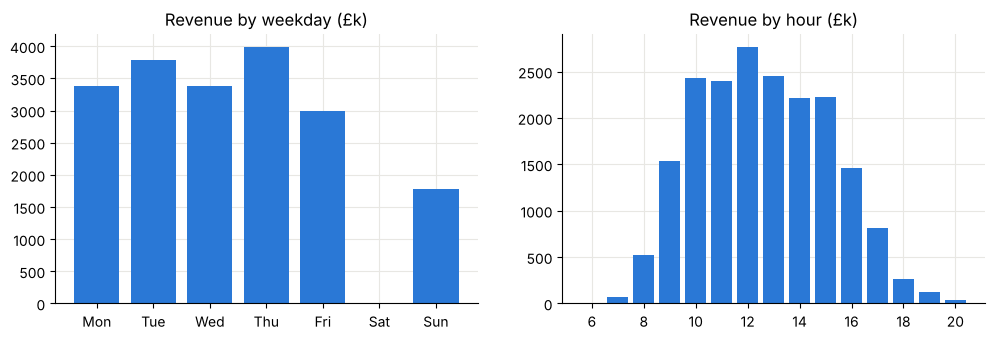

In [4]:
fig, (a, b) = plt.subplots(1, 2, figsize=(12, 3.5))
wd = an.sales_by_weekday(sales)
a.bar(wd["weekday"].str[:3], wd["revenue"] / 1e3, color=BLUE); a.set_title("Revenue by weekday (£k)")
hr = an.sales_by_hour(sales)
b.bar(hr["hour"], hr["revenue"] / 1e3, color=BLUE); b.set_title("Revenue by hour (£k)")
wd

Almost no Saturday trading (30 orders in two years – the business is closed), Thursday is the strongest day,
and orders cluster 10:00–15:00 (office hours of B2B buyers).

## 2. Products
### Best sellers

In [5]:
an.top_products(sales, 10)

,StockCode,description,revenue,units,orders
0,22423,REGENCY CAKESTAND 3 TIER,330590.32,26478,3918
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,248171.21,90343,5363
2,85099B,JUMBO BAG RED RETROSPOT,180569.34,96757,3989
3,47566,PARTY BUNTING,148318.28,28200,2674
4,84879,ASSORTED COLOUR BIRD ORNAMENT,129324.49,80082,2807
5,22086,PAPER CHAIN KIT 50'S CHRISTMAS,117760.29,35084,2018
6,79321,CHILLI LIGHTS,80540.88,15841,1135
7,22197,SMALL POPCORN HOLDER,79520.20,88499,2322
8,22386,JUMBO BAG PINK POLKADOT,76324.62,39437,2245
9,20725,LUNCH BAG RED RETROSPOT,71106.29,40317,3056


### Pareto: how concentrated is revenue?

Top 20% of products -> 78.4% of revenue
21.5% of products are needed for 80% of revenue (4,891 products)


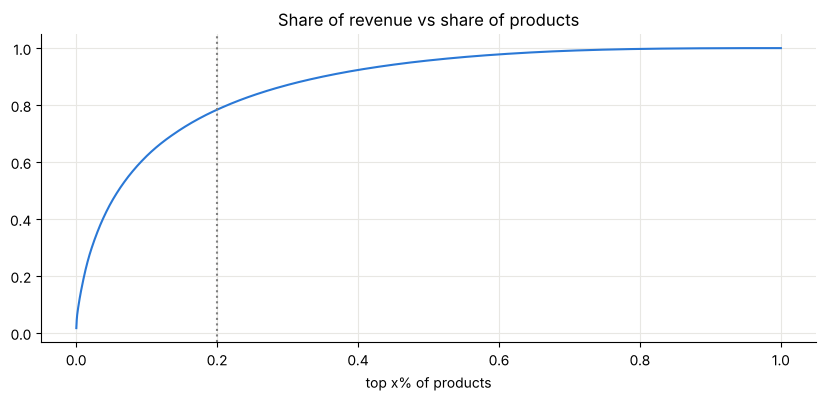

In [6]:
prod_rev = sales.groupby("StockCode", observed=True)["Revenue"].sum()
curve = an.pareto(prod_rev)
ax = curve.plot(x="rank_share", y="value_share", color=BLUE, legend=False)
ax.axvline(0.2, color="grey", ls=":"); ax.set(title="Share of revenue vs share of products", xlabel="top x% of products")
print(f"Top 20% of products -> {an.top_share(prod_rev, 0.2):.1%} of revenue")
print(f"{an.share_needed_for(prod_rev, 0.8):.1%} of products are needed for 80% of revenue ({len(prod_rev):,} products)")

### Return rates
Return rate = units returned / units sold. Products with fewer than 500 units sold are excluded, because one
return would swing their rate.

In [7]:
an.product_return_rates(sales, returns, min_units=500).head(10).round(3)

,StockCode,description,units_sold,revenue,units_returned,value_returned,return_rate
0,72045D,ROSES ON BLUE TEACUP CANDLE,539,918.65,504.0,851.76,0.935
1,23113,PANTRY CHOPPING BOARD,1154,5868.50,946.0,4803.06,0.820
2,23055,IVORY CHANDELIER T-LIGHT HOLDER,657,1395.18,432.0,690.72,0.658
3,79341,WILLOW BRANCH LIGHTS.,725,4423.69,448.0,2519.60,0.618
4,23056,FLOWERS CHANDELIER T-LIGHT HOLDER,963,2898.12,579.0,1859.07,0.601
5,23057,BEADED CHANDELIER T-LIGHT HOLDER,773,1768.67,433.0,636.15,0.560
6,84493,BLUE/PINK NEST STRIPE BOX,1142,111.12,567.0,45.36,0.496
7,84924F,PSYCHEDELIC METAL SIGN CALENDAR,975,274.55,480.0,120.00,0.492
8,37444B,BLUE BREAKFAST CUP AND SAUCER,2010,409.60,984.0,127.92,0.490
9,16202A,PASTEL PINK PHOTO ALBUM,662,290.45,324.0,97.80,0.489


Lighting and fragile homeware (candle teacups, chandelier T-light holders, chopping boards) dominate the
list – likely breakage or quality issues worth raising with suppliers.

## 3. Customers
### RFM segmentation
For each identified customer: **R**ecency (days since last order, at 10 Dec 2011), **F**requency (number of
orders), **M**onetary (total spend). Each is scored 1–5 by quintile (5 = best). Segment names come from the
widely used R×F map, e.g. R 5 & F 4–5 = Champions, R 1–2 & F 5 = Can't Lose Them.

In [8]:
rfm = an.rfm_table(sales)
rfm.sort_values("monetary", ascending=False).head()

,Customer ID,frequency,monetary,recency,R,F,M,segment
5666,18102,145,580987.04,0,5,5,5,Champions
2262,14646,145,526751.52,1,5,5,5,Champions
1778,14156,144,303069.88,9,5,5,5,Champions
2520,14911,373,272252.79,1,5,5,5,Champions
5026,17450,51,241616.25,8,5,5,5,Champions


In [9]:
seg = an.rfm_segments(rfm)
seg.round({"revenue": 0, "avg_recency": 0, "avg_frequency": 1, "avg_monetary": 0, "customer_share": 3, "revenue_share": 3})

,segment,customers,revenue,avg_recency,avg_frequency,avg_monetary,customer_share,revenue_share
0,Champions,826,8728660.0,8.0,19.3,10567.0,0.141,0.521
1,Loyal Customers,1155,4674697.0,66.0,9.8,4047.0,0.197,0.279
2,Potential Loyalists,710,643564.0,25.0,2.6,906.0,0.121,0.038
3,New Customers,52,18291.0,10.0,1.0,352.0,0.009,0.001
4,Promising,114,35727.0,37.0,1.0,313.0,0.019,0.002
5,Need Attention,270,339017.0,112.0,3.1,1256.0,0.046,0.020
6,About to Sleep,384,205675.0,105.0,1.4,536.0,0.066,0.012
7,At Risk,757,969347.0,371.0,3.9,1281.0,0.129,0.058
8,Can't Lose Them,72,503405.0,327.0,16.4,6992.0,0.012,0.030
9,Hibernating,1512,634581.0,456.0,1.2,420.0,0.258,0.038


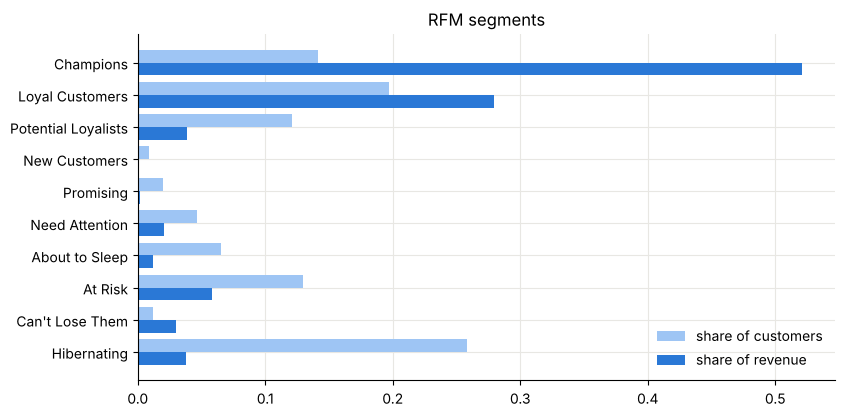

In [10]:
s = seg.iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(s["segment"], s["customer_share"], height=0.4, align="edge", color="#9ec5f4", label="share of customers")
ax.barh(s["segment"], s["revenue_share"], height=-0.4, align="edge", color=BLUE, label="share of revenue")
ax.legend(frameon=False); ax.set_title("RFM segments");

### Monthly cohort retention
Customers are grouped by the month of their first purchase; each cell is the share of that cohort that bought
again *n* months later. (The Dec-2009 cohort contains customers who already bought before the data starts, so
it looks unusually loyal.)

Average month-1 retention: 21.0%


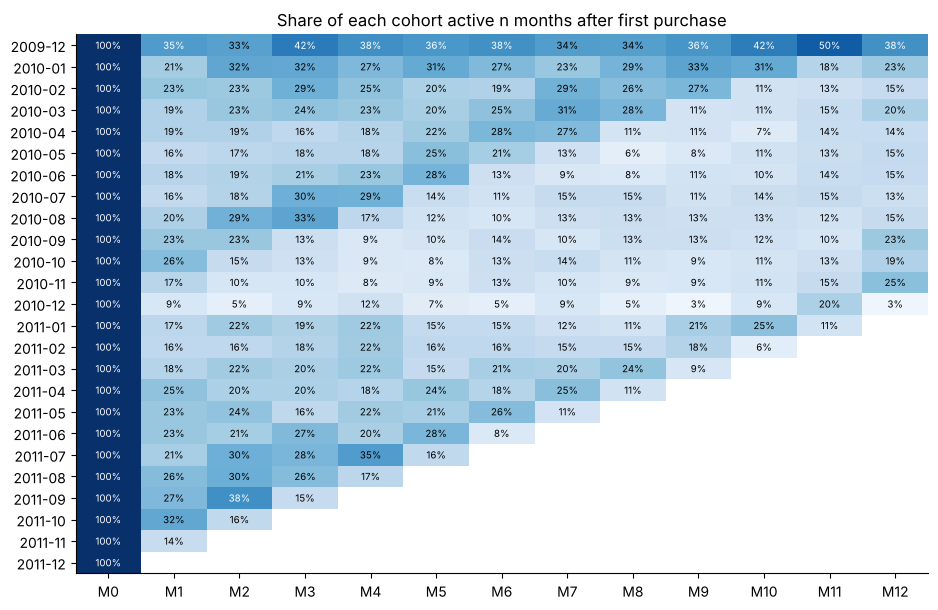

In [11]:
ret = an.cohort_retention(sales, max_months=12)
fig, ax = plt.subplots(figsize=(11, 7))
im = ax.imshow(ret.values, cmap="Blues", vmin=0, vmax=0.6, aspect="auto")
ax.set_xticks(range(ret.shape[1]), [f"M{c}" for c in ret.columns]); ax.set_yticks(range(len(ret)), ret.index)
ax.grid(False)
for i in range(ret.shape[0]):
    for j in range(ret.shape[1]):
        v = ret.values[i, j]
        if v == v:
            ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=7, color="white" if v > 0.35 else "black")
ax.set_title("Share of each cohort active n months after first purchase");
print(f"Average month-1 retention: {ret[1].mean():.1%}")

## 4. Countries

In [12]:
an.country_summary(sales).head(12).round({"revenue": 0, "aov": 0, "revenue_share": 3})

,Country,revenue,orders,customers,aov,revenue_share
0,United Kingdom,16498908.0,36178,5334,456.0,0.854
1,Ireland,623414.0,581,3,1073.0,0.032
2,Netherlands,549773.0,216,22,2545.0,0.028
3,Germany,383289.0,753,107,509.0,0.020
4,France,300668.0,598,93,503.0,0.016
5,Australia,167800.0,89,15,1885.0,0.009
6,Spain,97767.0,144,38,679.0,0.005
7,Switzerland,94025.0,85,22,1106.0,0.005
8,Sweden,86319.0,99,19,872.0,0.004
9,Denmark,63792.0,42,12,1519.0,0.003


## 5. Key findings for management

In [13]:
from IPython.display import Markdown
Markdown("\n".join(f"{i}. {t}" for i, t in enumerate(an.executive_insights(sales, returns), 1)))

1. **Customers are highly concentrated:** the top 20% of identified customers generate 77% of identified-customer revenue, and the 826 'Champions' (14% of customers) alone bring in 52%. Losing a handful of key accounts is the single biggest revenue risk.
2. **A small catalogue core drives sales:** 21% of the 4,891 products produce 80% of revenue; the top 20% produce 78%. The long tail is a candidate for stock rationalisation.
3. **Strong pre-Christmas season:** September-November months average £1,158,832 in revenue vs £654,752 in other months (+77%). The peak month was November 2011 (£1,451,576). Stock and staffing should be planned from August.
4. **Retention is the growth lever:** on average only 21% of new customers buy again in their second month, and 28% of identified customers ordered only once. A welcome / second-order campaign targets the largest leak.
5. **UK-heavy, but overseas orders are bigger:** the UK is 85% of revenue, yet the average non-UK order is £849 vs £456 for the UK. Returns cost £434,605 (2.2% of sales value).